In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
# Load the data
config = pd.read_csv('experiments/models/dataset_size/experiment_config.csv')
results = pd.read_csv('experiments/results/dataset_size.csv')

In [6]:
results['experiment'] = results['model_id'].apply(lambda x: x.split('_')[-1])
results['experiment'] = results['experiment'].astype(int)

In [7]:
# Merge the results and config DataFrames on the 'experiment' column
df = pd.merge(results, config, on='experiment', suffixes=('_results', '_config'))

In [8]:
df = df[(df['train_size'] == 0.9) & (df['val_size'] == 0.1)]

In [9]:
df['model'] = df['model_id'].apply(lambda x: x.split('_')[0])
# Create a new column 'dataset_quantity' as the product of 'dataset_size', 'train_size', and 'val_size'
df['train_size'] = df['train_size']*df['dataset_size']
df['val_size'] = df['val_size']*df['dataset_size']
df['dataset_size'] = df['train_size']+df['val_size']

In [ ]:
df

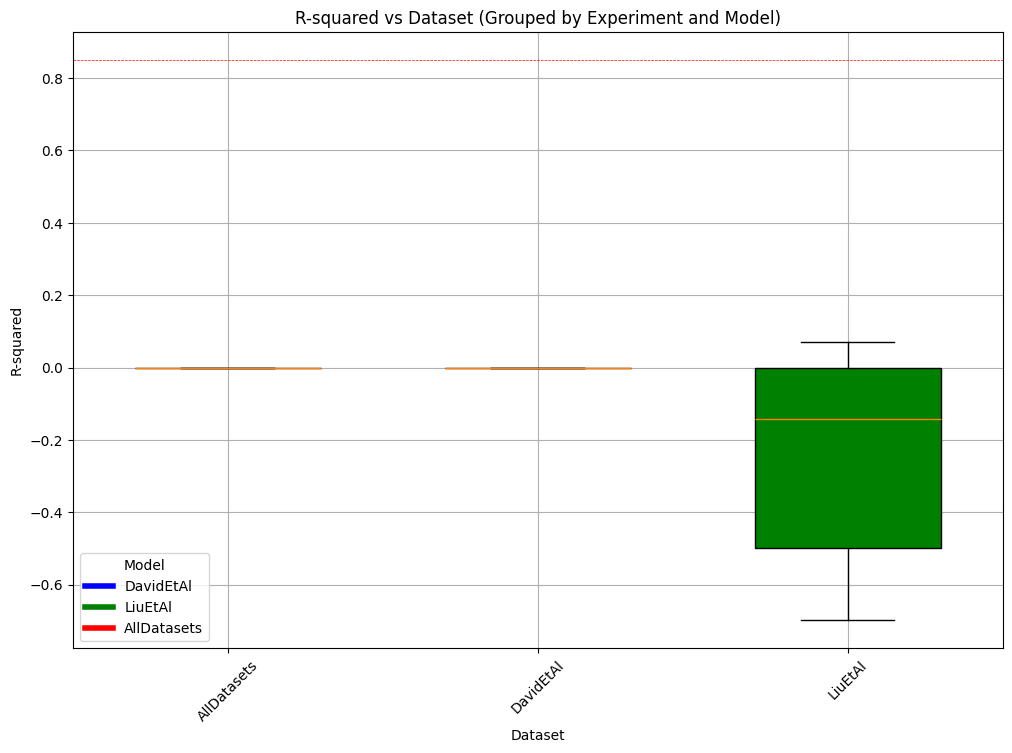

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# Initialize the filtered DataFrame
filtered_df = df.copy()

# Set NaN values in the 'r_squared' column to 0
filtered_df['r_squared'] = filtered_df['r_squared'].fillna(0)

# Filter the DataFrame to include both yolov8n and yolov5n models
filtered_df = filtered_df[filtered_df['out_domain'].isin(['yes'])]

# Group by 'experiment' and 'model' and select the observation with the highest R-squared value
filtered_df = filtered_df.loc[filtered_df.groupby(['experiment', 'model'])['r_squared'].idxmax()]

# Set r-squared <0 to 0
filtered_df = filtered_df[filtered_df['r_squared'] >= -1]

# Sort by dataset
filtered_df = filtered_df.sort_values(by='dataset')

# Define custom colors for each model
colors = {'DavidEtAl': 'blue', 'LiuEtAl': 'green', 'AllDatasets': 'red'}

# Create a figure and axis
plt.figure(figsize=(12, 8))

# Plot the data
datasets = filtered_df['dataset'].unique()
positions = range(len(datasets))
for i, dataset in enumerate(datasets):
    model_data = filtered_df[filtered_df['dataset'] == dataset]
    plt.boxplot(model_data['r_squared'], positions=[i], widths=0.6, patch_artist=True, boxprops=dict(facecolor=colors[dataset]))

# Plot a red line at y = 0.85
plt.axhline(y=0.85, color='red', linestyle='--', linewidth=0.5)

plt.xticks(positions, datasets, rotation=45)
plt.xlabel('Dataset')
plt.ylabel('R-squared')
plt.title('R-squared vs Dataset (Grouped by Experiment and Model)')
plt.grid(True)
plt.legend(handles=[plt.Line2D([0], [0], color=color, lw=4) for color in colors.values()], labels=colors.keys(), title='Model')

plt.show()

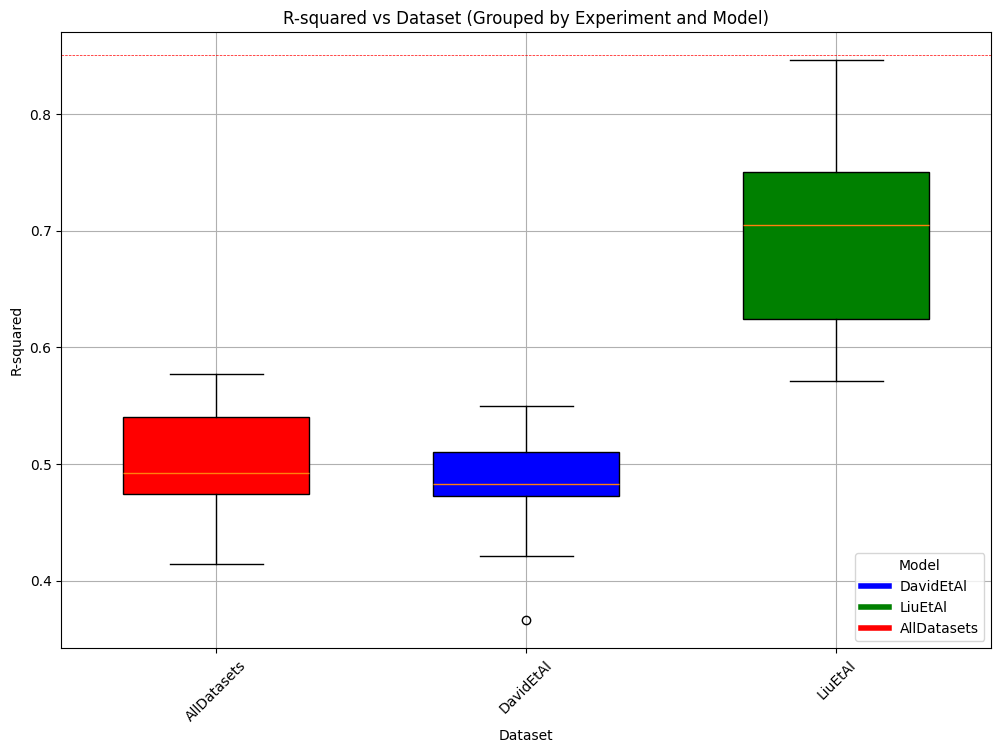

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# Initialize the filtered DataFrame
filtered_df = df.copy()

# Set NaN values in the 'count_accuracy_avg' column to 0
filtered_df['count_accuracy_avg'] = filtered_df['count_accuracy_avg'].fillna(0)

# Filter the DataFrame to include both yolov8n and yolov5n models
filtered_df = filtered_df[filtered_df['out_domain'].isin(['yes'])]

# Group by 'experiment' and 'model' and select the observation with the highest R-squared value
filtered_df = filtered_df.loc[filtered_df.groupby(['experiment', 'model'])['count_accuracy_avg'].idxmax()]

# Set r-squared <0 to 0
filtered_df = filtered_df[filtered_df['count_accuracy_avg'] >= -1]

# Sort by dataset
filtered_df = filtered_df.sort_values(by='dataset')

# Define custom colors for each model
colors = {'DavidEtAl': 'blue', 'LiuEtAl': 'green', 'AllDatasets': 'red'}

# Create a figure and axis
plt.figure(figsize=(12, 8))

# Plot the data
datasets = filtered_df['dataset'].unique()
positions = range(len(datasets))
for i, dataset in enumerate(datasets):
    model_data = filtered_df[filtered_df['dataset'] == dataset]
    plt.boxplot(model_data['count_accuracy_avg'], positions=[i], widths=0.6, patch_artist=True, boxprops=dict(facecolor=colors[dataset]))

# Plot a red line at y = 0.85
plt.axhline(y=0.85, color='red', linestyle='--', linewidth=0.5)

plt.xticks(positions, datasets, rotation=45)
plt.xlabel('Dataset')
plt.ylabel('R-squared')
plt.title('R-squared vs Dataset (Grouped by Experiment and Model)')
plt.grid(True)
plt.legend(handles=[plt.Line2D([0], [0], color=color, lw=4) for color in colors.values()], labels=colors.keys(), title='Model')

plt.show()

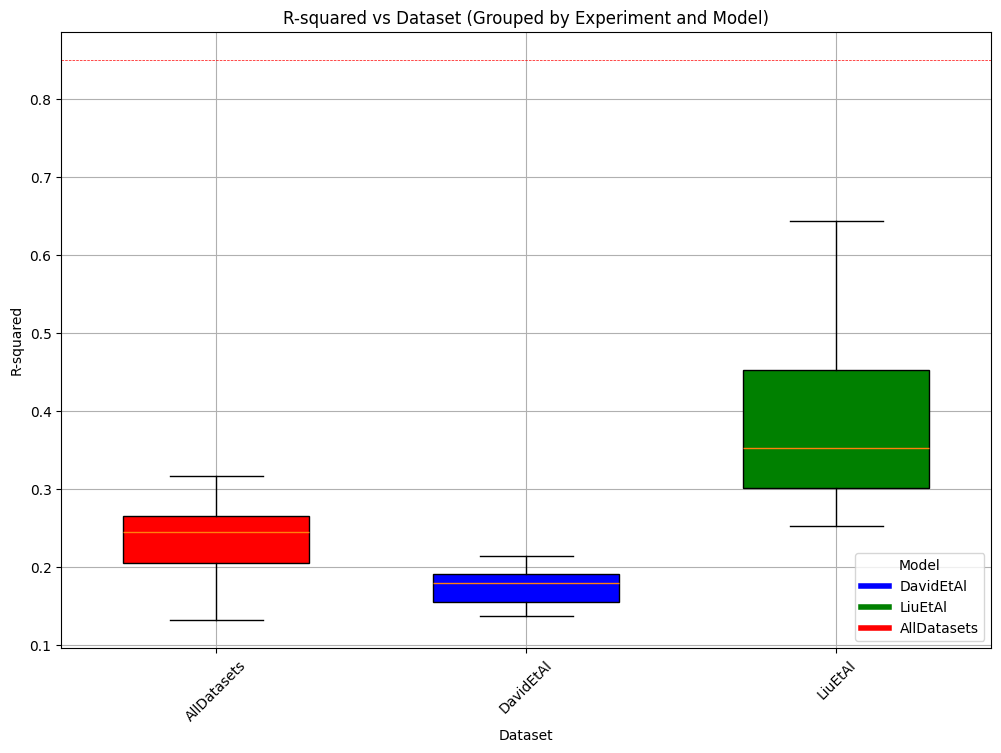

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# Initialize the filtered DataFrame
filtered_df = df.copy()

# Set NaN values in the 'ap_iou_50' column to 0
filtered_df['ap_iou_50'] = filtered_df['ap_iou_50'].fillna(0)

# Filter the DataFrame to include both yolov8n and yolov5n models
filtered_df = filtered_df[filtered_df['out_domain'].isin(['yes'])]

# Group by 'experiment' and 'model' and select the observation with the highest R-squared value
filtered_df = filtered_df.loc[filtered_df.groupby(['experiment', 'model'])['ap_iou_50'].idxmax()]

# Set r-squared <0 to 0
filtered_df = filtered_df[filtered_df['ap_iou_50'] >= -1]

# Sort by dataset
filtered_df = filtered_df.sort_values(by='dataset')

# Define custom colors for each model
colors = {'DavidEtAl': 'blue', 'LiuEtAl': 'green', 'AllDatasets': 'red'}

# Create a figure and axis
plt.figure(figsize=(12, 8))

# Plot the data
datasets = filtered_df['dataset'].unique()
positions = range(len(datasets))
for i, dataset in enumerate(datasets):
    model_data = filtered_df[filtered_df['dataset'] == dataset]
    plt.boxplot(model_data['ap_iou_50'], positions=[i], widths=0.6, patch_artist=True, boxprops=dict(facecolor=colors[dataset]))

# Plot a red line at y = 0.85
plt.axhline(y=0.85, color='red', linestyle='--', linewidth=0.5)

plt.xticks(positions, datasets, rotation=45)
plt.xlabel('Dataset')
plt.ylabel('R-squared')
plt.title('R-squared vs Dataset (Grouped by Experiment and Model)')
plt.grid(True)
plt.legend(handles=[plt.Line2D([0], [0], color=color, lw=4) for color in colors.values()], labels=colors.keys(), title='Model')

plt.show()